# Digital Signal Processing Assignment
## Convolution and Discrete Fourier Transform (DFT)

Name: T.Venugoban
Index No: 23002093  
Module: Digital Signal Processing

### Objective
- Generate noisy 50 Hz sine wave
- Apply 3-point moving average filter
- Implement manual convolution

## Part 1: Convolution

### Convolution in Digital Signal Processing

Convolution is the mathematical operation used to combine two signals to produce a third signal. In DSP systems, convolution describes how an input signal is modified by a system's impulse response.

For a discrete-time system:

y[n] = Σ x[i]h[n-i]

Where:
- x[n] = input signal
- h[n] = impulse response (filter)
- y[n] = output signal

In this assignment, a **3-point Moving Average Filter** is used as the impulse response. This filter smooths the signal by averaging three neighboring samples.

The convolution is implemented manually using the **Input-Side Algorithm**, where each input sample contributes a scaled version of the impulse response to the output signal.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
FS=1000
t=np.linspace(0,1,FS)

f=50
clean_signal=np.sin(2*np.pi*f*t)

noise=0.5*np.random.normal(size=FS)
noisy_signal=clean_signal+noise

### Define Moving Average Filter

### 3-Point Moving Average Filter

A moving average filter is a simple digital filter used to reduce noise in a signal.

The impulse response of the filter is:

h[n] = [1/3, 1/3, 1/3]

This means each output sample is calculated as the average of three consecutive input samples.

Moving average filters are commonly used for **signal smoothing and noise reduction**.

In [29]:
h=np.ones(3)/3

### Manual Convolution Implementation

In this section, convolution is implemented manually using nested loops.

The algorithm works by multiplying each input sample with the impulse response and accumulating the results to produce the output signal.

This implementation follows the **Input-Side Algorithm**, where each input sample contributes a scaled version of the impulse response to the output.

In [30]:
def manual_convolution(x,h):
    Nx=len(x)
    Nh=len(h)
    y=np.zeros(Nx+Nh-1)

    for i in range(Nx):
        for j in range(Nh):
            y[i+j]+=x[i]*h[j]
    return y

In [31]:
filtered_signal= manual_convolution(noisy_signal,h)

### Signal Visualization

The following plot compares the original noisy signal with the filtered signal after applying the moving average filter. The filter smooths the signal by reducing random noise.

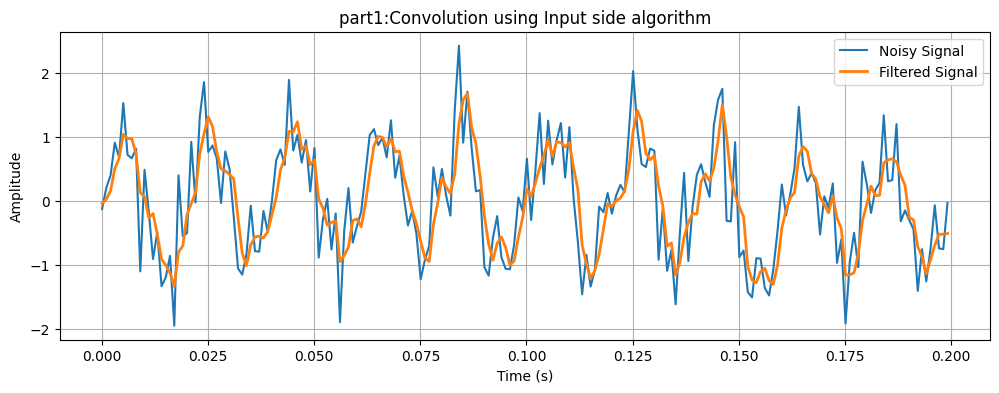

In [32]:
plt.figure(figsize=(12,4))
plt.plot(t[:200],noisy_signal[:200],label='Noisy Signal')
plt.plot(t[:200],filtered_signal[:200],label='Filtered Signal',linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title("part1:Convolution using Input side algorithm")
plt.grid(True)
plt.legend()
plt.show()

# Part 2: Manual Discrete Fourier Transform (DFT)
This section implements DFT manually using cosine and sine basis functions.

## Objective
- Generate a signal containing 60 Hz and 120 Hz components.
- Implement DFT manually (without using numpy.fft).
- Compute Real and Imaginary parts.
- Calculate the magnitude spectrum.
- Identify frequency peaks.

## Part 2: Discrete Fourier Transform (DFT)

The Discrete Fourier Transform (DFT) converts a signal from the **time domain** into the **frequency domain**.

It allows us to analyze the frequency components present in a signal.

The DFT equations are:

ReX[k] = Σ x[i] cos(2πki/N)

ImX[k] = − Σ x[i] sin(2πki/N)

Where:
- x[i] is the input signal
- N is the number of samples
- k represents the frequency bin

The magnitude of each frequency component is calculated as:

MagX[k] = √(ReX[k]² + ImX[k]²)

In [33]:
FS=1000
N=1000
t=np.linspace(0,1,N)

## Signal Generation
60 Hz + 120 Hz sine wave
Sampling Frequency = 1000 Hz
Duration = 1 second

In [34]:
signal_dft=np.sin(2*np.pi*60*t)+0.5*np.sin(2*np.pi*120*t)

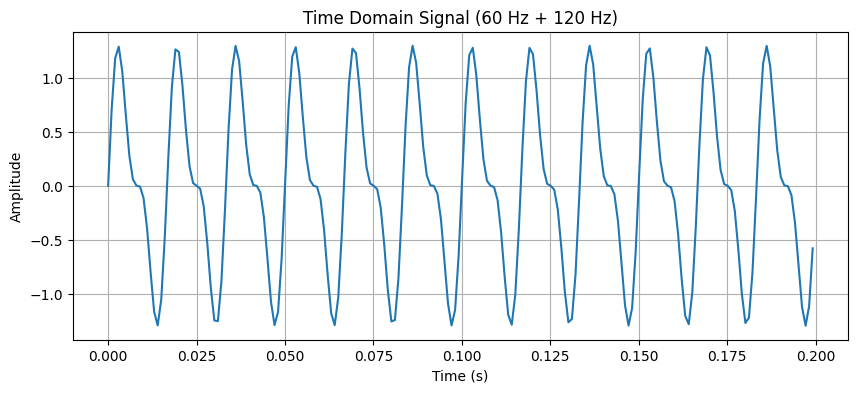

In [35]:
plt.figure(figsize=(10,4))
plt.plot(t[:200],signal_dft[:200])
plt.title("Time Domain Signal (60 Hz + 120 Hz)")
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### Manual DFT Implementation

The DFT is implemented manually using nested loops.

For each frequency index k, the algorithm calculates the real and imaginary components using cosine and sine functions.

This process measures how strongly each frequency is present in the signal.

In [36]:
def calculate_dft(x):
    N=len(x)
    ReX=np.zeros(N)
    ImX=np.zeros(N)

    for k in range(N):
        for i in range(N):
            angle=2*np.pi*k*i/N
            ReX[k]+=x[i]*np.cos(angle)
            ImX[k]-=x[i]*np.sin(angle)

    MagX=np.sqrt(ReX**2+ImX**2)
    return MagX

In [37]:
mag=calculate_dft(signal_dft)

In [38]:
freq=np.arange(N)*(FS/N)

### Magnitude Spectrum

The magnitude spectrum shows the strength of each frequency component present in the signal.

In this example, peaks are expected at **60 Hz and 120 Hz**, corresponding to the sine waves used to generate the signal.

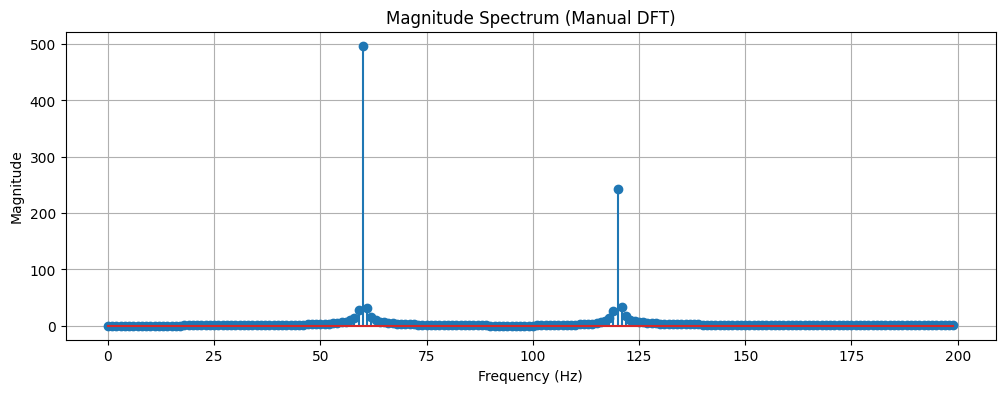

In [39]:
plt.figure(figsize=(12,4))
plt.stem(freq[:200],mag[:200])
plt.title("Magnitude Spectrum (Manual DFT)")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

## Conclusion

The convolution operation successfully reduced noise in the signal using a moving average filter.

The manually implemented DFT correctly identified the dominant frequencies in the signal, showing clear peaks at approximately **60 Hz and 120 Hz**.

This demonstrates how convolution is used for signal filtering and how the DFT is used for frequency analysis in digital signal processing.